# 드론 프로펠러 소요전력 계산 — 이론 및 다방법 비교 검증

이 노트북은 멀티콥터용 프로펠러의 소요전력을 **세 가지 독립적인 방법**으로 계산하고,
LG 슬라이드 9 실측치와 비교하여 상호 검증합니다.

| 방법 | 이론 | 필요 입력 | 특징 |
|---|---|---|---|
| **Method A** | BEMT 계수 (Ct, Cp) | RPM, D, Ct, Cp | RPM별 세부 거동 가능 |
| **Method B** | 액추에이터 디스크 + FM | T, D, FM | RPM 불필요, 설계 초기 단계 |
| **Method C** | aerosandbox 내장 | T, D, V | 공식 라이브러리 |

모두 동일한 물리(뉴턴 제3법칙 + 에너지 보존)를 다른 각도로 표현한 것입니다.


## 0. 환경 설정 및 공통 파라미터

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import aerosandbox as asb
from aerosandbox.library.propulsion_propeller import propeller_shaft_power_from_thrust

# ── 한글 폰트 설정 ──────────────────────────────────────────────────────────
for _fp in ['/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
            '/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc']:
    fm.fontManager.addfont(_fp)
plt.rcParams['font.family'] = 'Noto Sans CJK JP'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110

# ── 공기밀도 (aerosandbox Atmosphere 사용) ──────────────────────────────────
atm   = asb.Atmosphere(altitude=0)   # 해수면 표준대기
rho   = atm.density()                # [kg/m³]
print(f"공기밀도 rho = {rho:.4f} kg/m³")

# ── 프로펠러 정의 (LG 슬라이드 9 역산 교정값) ─────────────────────────────
# Ct/Cp: T = Ct*rho*n^2*D^4,  P = Cp*rho*n^3*D^5  에서 역산
props = {
    "Phi35 / 12x4CF (LG Plat-A)": dict(
        D_in  = 12,       # 직경 [inch]
        Ct    = 0.100,    # 추력계수 (역산)
        Cp    = 0.046,    # 동력계수 (역산)
        RPM_range = (2000, 10000),
        T_max_kgf = 2.2,
        color = "#2196F3",
        lg_pts = [(5727, 1.0, 8.0), (8095, 2.0, 5.5)],  # (RPM, kgf, gf/W)
    ),
    "Phi52 / 18x6.5CF (LG Plat-B)": dict(
        D_in  = 18,
        Ct    = 0.095,
        Cp    = 0.039,
        RPM_range = (1000, 6000),
        T_max_kgf = 5.5,
        color = "#4CAF50",
        lg_pts = [(3633, 2.0, 9.5), (5500, 5.0, 5.5)],
    ),
    "Phi82 / 22x8CF (LG Plat-C, 추산)": dict(
        D_in  = 22,
        Ct    = 0.098,
        Cp    = 0.042,
        RPM_range = (500, 4000),
        T_max_kgf = 12.0,
        color = "#FF5722",
        lg_pts = [],
    ),
}
print("프로펠러 정의 완료:", list(props.keys()))


공기밀도 rho = 1.2250 kg/m³
프로펠러 정의 완료: ['Phi35 / 12x4CF (LG Plat-A)', 'Phi52 / 18x6.5CF (LG Plat-B)', 'Phi82 / 22x8CF (LG Plat-C, 추산)']


---
## 1. Method A — BEMT 무차원 계수법 (Blade Element Momentum Theory)

### 이론

프로펠러 공력은 무차원 계수 **Ct, Cp** 로 표현합니다.

$$T = C_t \cdot \rho \cdot n^2 \cdot D^4$$

$$P = C_p \cdot \rho \cdot n^3 \cdot D^5$$

$$\eta \;[\text{gf/W}] = \frac{T[\text{kgf}] \times 1000}{P[\text{W}]}$$

| 기호 | 의미 | 단위 |
|---|---|---|
| $n$ | 회전속도 ($n = RPM / 60$) | rev/s |
| $D$ | 프로펠러 직경 | m |
| $C_t$ | 추력계수 (프로펠러 형상·피치에 의존) | — |
| $C_p$ | 동력계수 | — |
| $\rho$ | 공기밀도 | kg/m³ |

### Ct, Cp 역산 방법

LG 슬라이드 9에서 **(RPM, T)** 쌍을 읽어 Ct를 역산합니다:

$$C_t = \frac{T}{\rho \cdot n^2 \cdot D^4}$$

Cp는 동일 조건 전력을 추정하거나, $C_p / C_t \approx 0.45$ (호버용 일반값) 비율을 씁니다.

### 전진비 (Advance Ratio)

$$J = \frac{V_{\infty}}{n \cdot D}$$

호버 조건에서 $J = 0$. 전진 비행에서는 $J > 0$ 이 되어 Ct, Cp 값이 변합니다.
이 노트북은 호버($J = 0$) 조건을 다룹니다.


Method A: BEMT 무차원 계수법
  Phi35 / 12 | RPM= 5727 | T=1.0kgf | η_calc=7.62 | η_LG=8.0 gf/W
  Phi35 / 12 | RPM= 8095 | T=2.0kgf | η_calc=5.39 | η_LG=5.5 gf/W
  Phi52 / 18 | RPM= 3633 | T=2.0kgf | η_calc=8.97 | η_LG=9.5 gf/W
  Phi52 / 18 | RPM= 5500 | T=5.0kgf | η_calc=5.92 | η_LG=5.5 gf/W


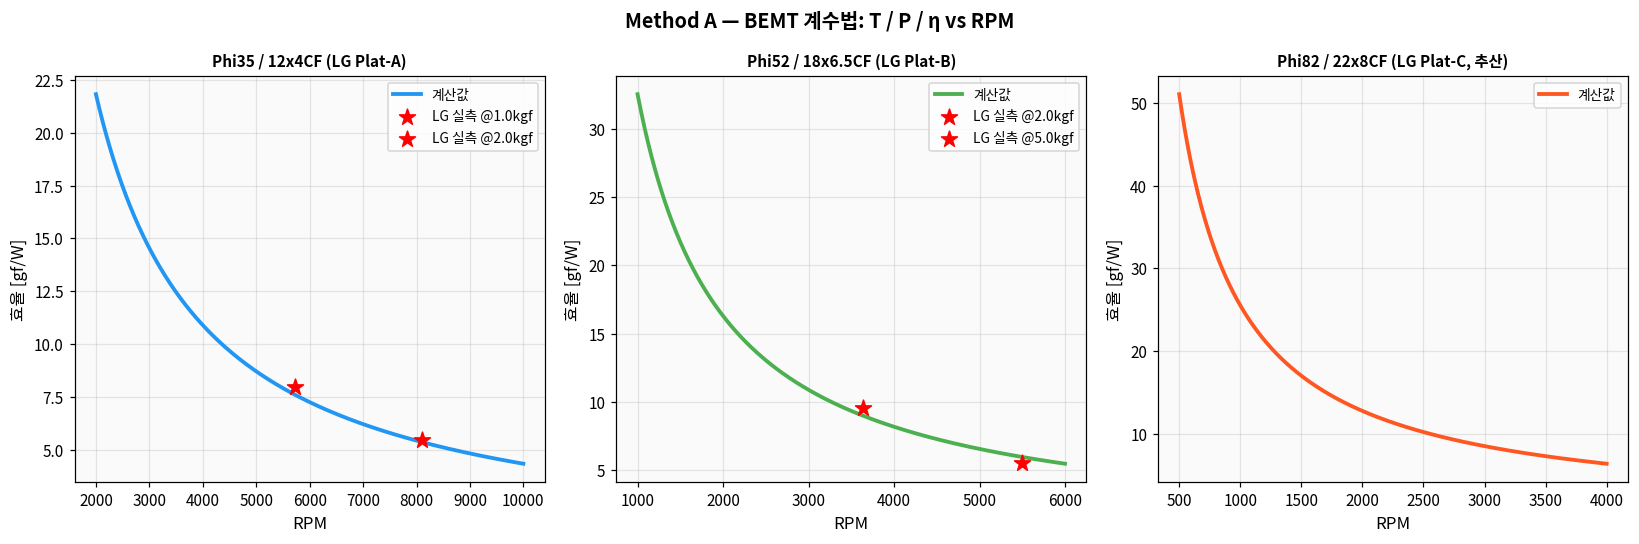


Method A 계산 완료.


In [2]:
# ── Method A: BEMT 계수법 계산 ─────────────────────────────────────────────
print("=" * 60)
print("Method A: BEMT 무차원 계수법")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Method A — BEMT 계수법: T / P / η vs RPM", fontsize=13, fontweight="bold")

for ax, (pname, pd) in zip(axes, props.items()):
    D   = pd["D_in"] * 0.0254      # inch → m
    Ct  = pd["Ct"]
    Cp  = pd["Cp"]
    col = pd["color"]
    rpms = np.linspace(*pd["RPM_range"], 500)
    n    = rpms / 60               # rev/s

    T_N   = Ct * rho * n**2 * D**4   # [N]
    P_W   = Cp * rho * n**3 * D**5   # [W]
    T_kgf = T_N / 9.81
    eta   = T_kgf * 1000 / P_W       # [gf/W]

    ax.plot(rpms, eta, color=col, lw=2.5, label="계산값")
    ax.set_xlabel("RPM", fontsize=11)
    ax.set_ylabel("효율 [gf/W]", fontsize=11)
    ax.set_title(pname, fontsize=10, fontweight="bold")
    ax.grid(True, alpha=0.3)

    # LG 실측점 표시
    for rpm_m, t_m, e_m in pd["lg_pts"]:
        ax.scatter(rpm_m, e_m, color="red", s=120, zorder=8,
                   marker="*", label=f"LG 실측 @{t_m}kgf")
        print(f"  {pname[:10]} | RPM={rpm_m:5d} | T={t_m:.1f}kgf "
              f"| η_calc={Ct*rho*(rpm_m/60)**2*(pd['D_in']*0.0254)**4 / 9.81 * 1000 / (Cp*rho*(rpm_m/60)**3*(pd['D_in']*0.0254)**5):.2f} "
              f"| η_LG={e_m:.1f} gf/W")

    ax.legend(fontsize=9)
    ax.set_facecolor("#FAFAFA")

plt.tight_layout()
plt.savefig("method_A_BEMT.png", dpi=130, bbox_inches="tight")
plt.show()
print("\nMethod A 계산 완료.")


---
## 2. Method B — 액추에이터 디스크 이론 (Momentum Theory)

### 이론

프로펠러를 공기를 가속하는 **무한히 얇은 원판**으로 모델링합니다.

**기본 가정:** 원판을 통과하는 공기는 위→아래로 $v_i$ (유도속도) 만큼 가속됩니다.

$$v_i = \sqrt{\frac{T}{2 \rho A}}$$

$$A = \frac{\pi D^2}{4} \quad \text{(원판 면적)}$$

호버에서의 **이상적 소요전력 (유도 동력)**:

$$P_{\text{ideal}} = T \cdot v_i = T \cdot \sqrt{\frac{T}{2 \rho A}} = \frac{T^{3/2}}{\sqrt{2 \rho A}}$$

실제 프로펠러는 점성손실·팁 손실 등이 있으므로:

$$P_{\text{actual}} = \frac{P_{\text{ideal}}}{FM}$$

**FM (Figure of Merit):** 이상 동력 / 실제 동력, 일반적으로 0.65~0.85.
잘 설계된 멀티콥터 프로펠러는 FM ≈ 0.75~0.80.

### FM 역산

LG 실측치 $(T, \eta_{\text{LG}})$ 에서 실제 전력 $P_{\text{actual}} = T \times 1000 / \eta_{\text{LG}}$ 을 구하면:

$$FM = \frac{P_{\text{ideal}}}{P_{\text{actual}}}$$


Method B: 액추에이터 디스크 이론

▶ LG 실측치에서 FM 역산:
  Phi35 / 12 | T=1.0kgf | P_actual=125.0W | P_ideal=72.7W | FM=0.581
  Phi35 / 12 | T=2.0kgf | P_actual=363.6W | P_ideal=205.5W | FM=0.565
  Phi52 / 18 | T=2.0kgf | P_actual=210.5W | P_ideal=137.0W | FM=0.651
  Phi52 / 18 | T=5.0kgf | P_actual=909.1W | P_ideal=541.7W | FM=0.596


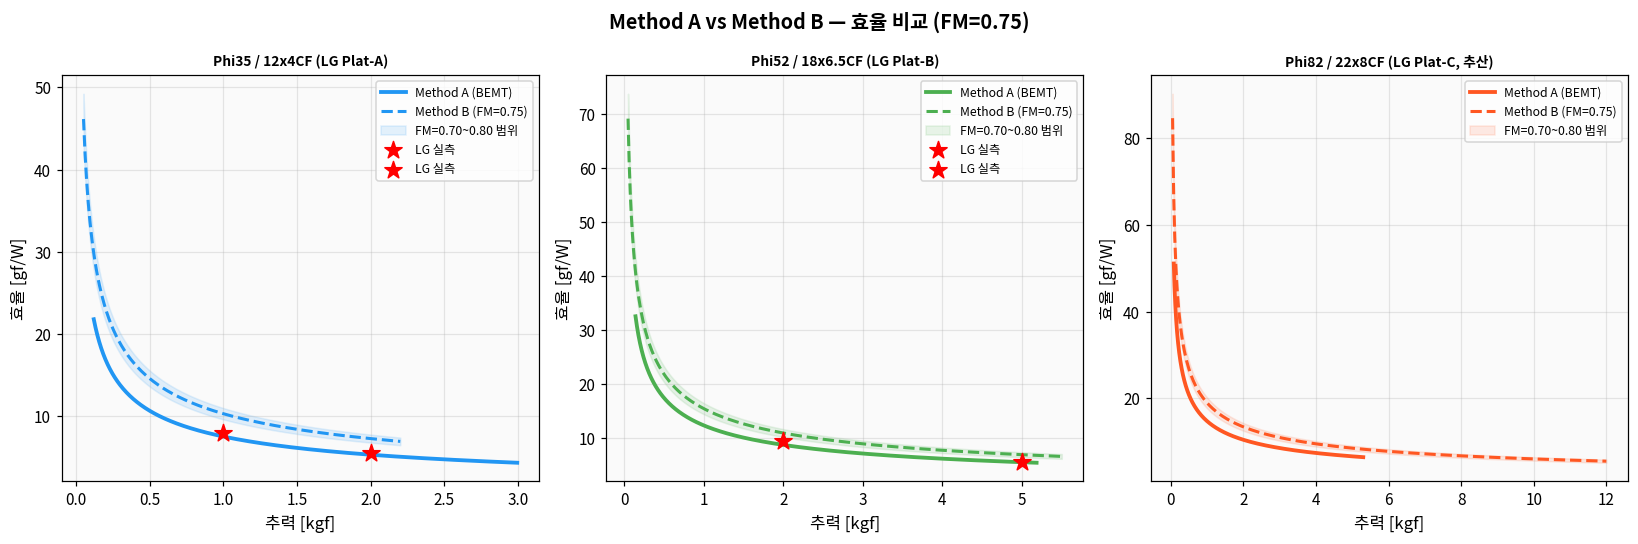

In [3]:
# ── Method B: 액추에이터 디스크 이론 ──────────────────────────────────────
print("=" * 60)
print("Method B: 액추에이터 디스크 이론")
print("=" * 60)

def actuator_disk_power(T_N, D_m, FM=0.75):
    """
    호버 소요전력 (액추에이터 디스크)
    T_N : 추력 [N]
    D_m : 직경 [m]
    FM  : Figure of Merit (기본 0.75)
    반환: P_W [W]
    """
    A       = np.pi * D_m**2 / 4       # 원판 면적 [m^2]
    v_i     = np.sqrt(T_N / (2 * rho * A))   # 유도속도 [m/s]
    P_ideal = T_N * v_i                       # 이상 동력 [W]
    P_actual = P_ideal / FM                   # 실제 동력 [W]
    return P_actual, P_ideal, v_i

# ── LG 실측에서 FM 역산 ────────────────────────────────────────────────────
print("\n▶ LG 실측치에서 FM 역산:")
for pname, pd in props.items():
    D = pd["D_in"] * 0.0254
    A = np.pi * D**2 / 4
    for rpm_m, t_m, e_m in pd["lg_pts"]:
        T_N = t_m * 9.81
        P_actual = t_m * 1000 / e_m       # 실제 전력 [W]
        P_ideal  = T_N * np.sqrt(T_N / (2 * rho * A))
        FM       = P_ideal / P_actual
        print(f"  {pname[:10]} | T={t_m:.1f}kgf | P_actual={P_actual:.1f}W | "
              f"P_ideal={P_ideal:.1f}W | FM={FM:.3f}")

# ── FM=0.75로 추력 범위 계산 및 Method A 비교 ──────────────────────────────
FM_nom = 0.75   # 공칭 FM

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Method A vs Method B — 효율 비교 (FM=0.75)", fontsize=13, fontweight="bold")

for ax, (pname, pd) in zip(axes, props.items()):
    D   = pd["D_in"] * 0.0254
    col = pd["color"]
    Ct, Cp = pd["Ct"], pd["Cp"]

    # Method A (BEMT)
    rpms   = np.linspace(*pd["RPM_range"], 500)
    n      = rpms / 60
    T_A    = Ct * rho * n**2 * D**4
    P_A    = Cp * rho * n**3 * D**5
    eta_A  = T_A / 9.81 * 1000 / P_A

    # Method B (Actuator Disk)
    T_range = np.linspace(0.05 * 9.81, pd["T_max_kgf"] * 9.81, 400)
    P_B, _, _ = actuator_disk_power(T_range, D, FM=FM_nom)
    eta_B     = (T_range / 9.81 * 1000) / P_B

    ax.plot(T_A / 9.81, eta_A, color=col, lw=2.5, label="Method A (BEMT)")
    ax.plot(T_range / 9.81, eta_B, color=col, lw=2, ls="--", label=f"Method B (FM={FM_nom})")

    # FM 범위 음영 (0.70~0.80)
    P_lo, _, _ = actuator_disk_power(T_range, D, FM=0.80)
    P_hi, _, _ = actuator_disk_power(T_range, D, FM=0.70)
    eta_lo = (T_range / 9.81 * 1000) / P_lo
    eta_hi = (T_range / 9.81 * 1000) / P_hi
    ax.fill_between(T_range / 9.81, eta_lo, eta_hi, color=col, alpha=0.12, label="FM=0.70~0.80 범위")

    # LG 실측점
    for rpm_m, t_m, e_m in pd["lg_pts"]:
        ax.scatter(t_m, e_m, color="red", s=140, zorder=9, marker="*", label="LG 실측")

    ax.set_xlabel("추력 [kgf]", fontsize=11)
    ax.set_ylabel("효율 [gf/W]", fontsize=11)
    ax.set_title(pname, fontsize=9, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    ax.set_facecolor("#FAFAFA")

plt.tight_layout()
plt.savefig("method_AB_compare.png", dpi=130, bbox_inches="tight")
plt.show()


---
## 3. Method C — aerosandbox 내장 함수

### 이론

aerosandbox의 `propeller_shaft_power_from_thrust()` 는 동적 원판 이론 공식입니다:

$$P = \frac{1}{2} T V \left( \sqrt{\frac{T}{A V^2 \rho / 2} + 1} + 1 \right) \cdot \frac{1}{COP}$$

- $V$ = 비행속도 [m/s]
- $COP$ = 성능계수 (기본값 0.8, FM과 유사한 개념)

**호버 극한 ($V \to 0$) 에서 로피탈 적용:**

$$\lim_{V \to 0} P = T \cdot \sqrt{\frac{T}{2 \rho A}} \cdot \frac{1}{COP}$$

즉, Method B와 동일한 공식으로 귀결됩니다. ($COP = FM$)

**차이점:** Method B는 FM을 명시적으로 입력하지만,
aerosandbox 함수는 전진 비행($V > 0$)에서도 일관된 공식을 제공합니다.


Method C: aerosandbox propeller_shaft_power_from_thrust()


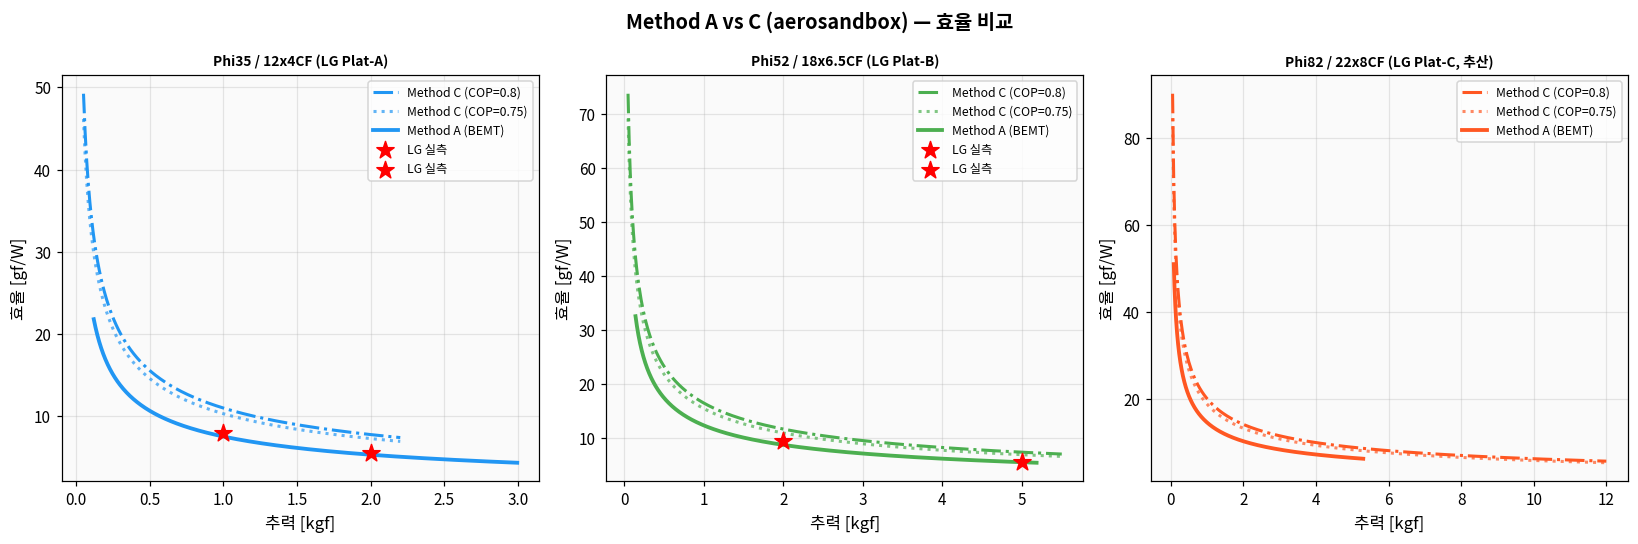

In [4]:
# ── Method C: aerosandbox 내장 함수 ────────────────────────────────────────
print("=" * 60)
print("Method C: aerosandbox propeller_shaft_power_from_thrust()")
print("=" * 60)

# 호버에서 V=0 이면 수치 문제 → 아주 작은 값으로 근사
V_hover = 0.001  # m/s (≈ 정지)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Method A vs C (aerosandbox) — 효율 비교", fontsize=13, fontweight="bold")

for ax, (pname, pd) in zip(axes, props.items()):
    D   = pd["D_in"] * 0.0254
    col = pd["color"]
    Ct, Cp = pd["Ct"], pd["Cp"]
    A   = np.pi * D**2 / 4

    # Method A (BEMT)
    rpms  = np.linspace(*pd["RPM_range"], 500)
    n     = rpms / 60
    T_A   = Ct * rho * n**2 * D**4
    P_A   = Cp * rho * n**3 * D**5
    eta_A = T_A / 9.81 * 1000 / P_A

    # Method C (aerosandbox, COP=0.75~0.80 범위)
    T_range = np.linspace(0.05 * 9.81, pd["T_max_kgf"] * 9.81, 400)
    for cop, ls, alpha in [(0.80, "-.", 1.0), (0.75, ":", 0.7)]:
        P_C   = propeller_shaft_power_from_thrust(
                    thrust_force = T_range,
                    area_propulsive = A,
                    airspeed = V_hover,
                    rho = rho,
                    propeller_coefficient_of_performance = cop,
                )
        eta_C = (T_range / 9.81 * 1000) / P_C
        ax.plot(T_range / 9.81, eta_C, color=col, lw=2, ls=ls,
                label=f"Method C (COP={cop})", alpha=alpha)

    ax.plot(T_A / 9.81, eta_A, color=col, lw=2.5, label="Method A (BEMT)")

    for rpm_m, t_m, e_m in pd["lg_pts"]:
        ax.scatter(t_m, e_m, color="red", s=140, zorder=9, marker="*", label="LG 실측")

    ax.set_xlabel("추력 [kgf]", fontsize=11)
    ax.set_ylabel("효율 [gf/W]", fontsize=11)
    ax.set_title(pname, fontsize=9, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    ax.set_facecolor("#FAFAFA")

plt.tight_layout()
plt.savefig("method_AC_compare.png", dpi=130, bbox_inches="tight")
plt.show()


---
## 4. 3방법 종합 비교 + LG 실측 검증

각 방법의 계산값과 LG 슬라이드 9 실측치를 함께 표시합니다.


In [5]:
# ── 3방법 종합 비교표 ──────────────────────────────────────────────────────
print("=" * 70)
print("LG 실측치 vs 세 방법 계산 비교표")
print("=" * 70)

rows = []
for pname, pd in props.items():
    D   = pd["D_in"] * 0.0254
    A   = np.pi * D**2 / 4
    Ct, Cp = pd["Ct"], pd["Cp"]

    for rpm_m, t_m, e_m in pd["lg_pts"]:
        T_N = t_m * 9.81
        n   = rpm_m / 60

        # Method A
        T_A  = Ct * rho * n**2 * D**4
        P_A  = Cp * rho * n**3 * D**5
        eta_A = T_A / 9.81 * 1000 / P_A

        # Method B (FM=0.75)
        P_B, _, vi = actuator_disk_power(T_N, D, FM=0.75)
        eta_B = t_m * 1000 / P_B

        # Method C (COP=0.77, aerosandbox)
        P_C  = propeller_shaft_power_from_thrust(
                   thrust_force=T_N, area_propulsive=A,
                   airspeed=0.001, rho=rho,
                   propeller_coefficient_of_performance=0.77)
        eta_C = t_m * 1000 / P_C

        rows.append({
            "프로펠러":       pname[:15],
            "RPM":            rpm_m,
            "추력[kgf]":     t_m,
            "LG실측[gf/W]":  e_m,
            "A:BEMT[gf/W]":  round(eta_A, 2),
            "B:ActDisk[gf/W]": round(eta_B, 2),
            "C:ASB[gf/W]":   round(eta_C, 2),
            "A오차[%]":      round((eta_A - e_m) / e_m * 100, 1),
            "B오차[%]":      round((eta_B - e_m) / e_m * 100, 1),
            "C오차[%]":      round((eta_C - e_m) / e_m * 100, 1),
        })

df = pd_module = __import__('pandas')
df = pd_module.DataFrame(rows)
print(df.to_string(index=False))


LG 실측치 vs 세 방법 계산 비교표
           프로펠러  RPM  추력[kgf]  LG실측[gf/W]  A:BEMT[gf/W]  B:ActDisk[gf/W]  C:ASB[gf/W]  A오차[%]  B오차[%]  C오차[%]
Phi35 / 12x4CF  5727      1.0         8.0          7.62            10.32        10.59    -4.8    29.0    32.4
Phi35 / 12x4CF  8095      2.0         5.5          5.39             7.30         7.49    -2.0    32.7    36.2
Phi52 / 18x6.5C 3633      2.0         9.5          8.97            10.95        11.24    -5.6    15.2    18.3
Phi52 / 18x6.5C 5500      5.0         5.5          5.92             6.92         7.11     7.7    25.9    29.2


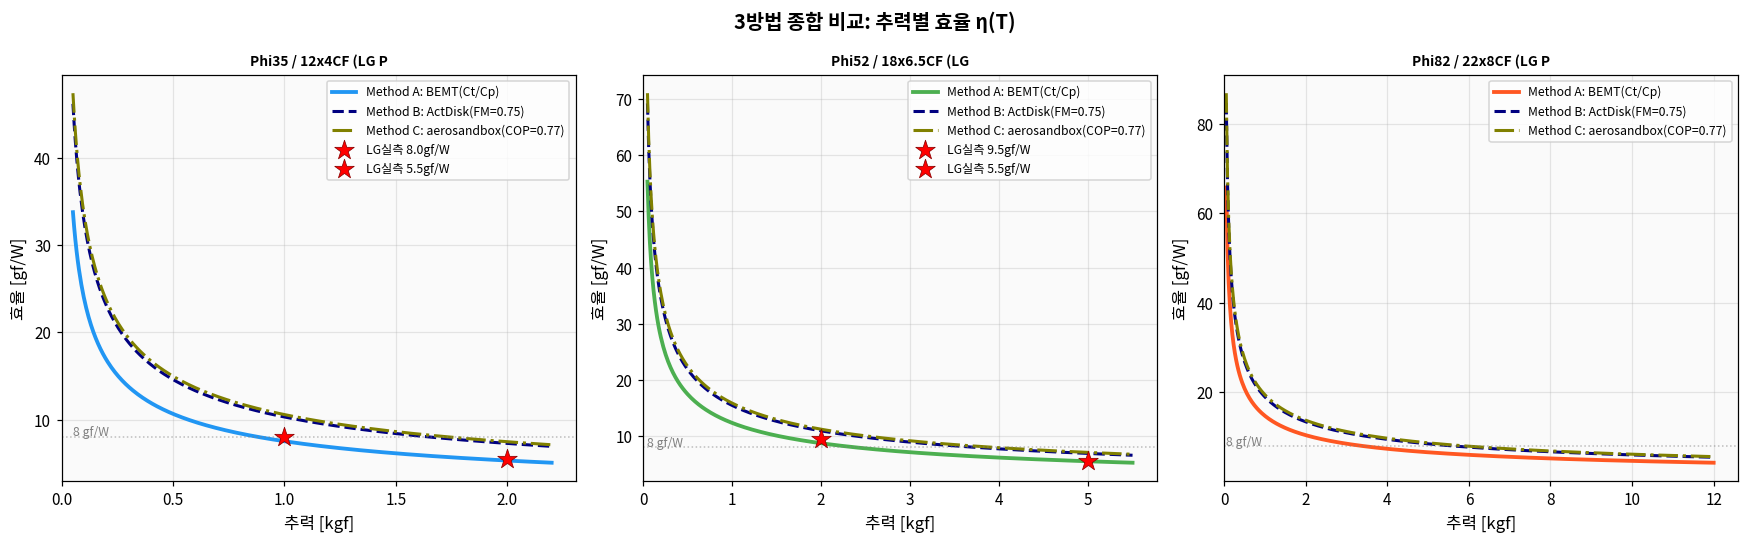

In [6]:
import pandas as pd  # 명시적 재임포트

# ── 3방법 η(T) 곡선 비교 — 전체 추력 범위 ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("3방법 종합 비교: 추력별 효율 η(T)", fontsize=13, fontweight="bold")

for ax, (pname, pd) in zip(axes, props.items()):
    D   = pd["D_in"] * 0.0254
    A   = np.pi * D**2 / 4
    Ct, Cp = pd["Ct"], pd["Cp"]
    col = pd["color"]
    T_range = np.linspace(0.05 * 9.81, pd["T_max_kgf"] * 9.81, 400)
    T_kgf   = T_range / 9.81

    # Method A (requires converting T → RPM)
    n_A    = np.sqrt(T_range / (Ct * rho * D**4))
    P_A    = Cp * rho * n_A**3 * D**5
    eta_A  = T_kgf * 1000 / P_A

    # Method B (FM=0.75)
    P_B, _, _ = actuator_disk_power(T_range, D, FM=0.75)
    eta_B  = T_kgf * 1000 / P_B

    # Method C (aerosandbox, COP=0.77)
    P_C    = propeller_shaft_power_from_thrust(
                 thrust_force=T_range, area_propulsive=A,
                 airspeed=0.001, rho=rho,
                 propeller_coefficient_of_performance=0.77)
    eta_C  = T_kgf * 1000 / P_C

    ax.plot(T_kgf, eta_A, color=col,     lw=2.5, label="Method A: BEMT(Ct/Cp)")
    ax.plot(T_kgf, eta_B, color="navy",  lw=2,   ls="--", label="Method B: ActDisk(FM=0.75)")
    ax.plot(T_kgf, eta_C, color="olive", lw=2,   ls="-.", label="Method C: aerosandbox(COP=0.77)")

    # LG 실측
    for rpm_m, t_m, e_m in pd["lg_pts"]:
        ax.scatter(t_m, e_m, color="red", s=180, zorder=10,
                   marker="*", edgecolors="darkred", lw=0.5,
                   label=f"LG실측 {e_m}gf/W")

    ax.axhline(8, color="gray", ls=":", lw=1, alpha=0.5)
    ax.text(0.05, 8.15, "8 gf/W", fontsize=8, color="gray")
    ax.set_xlabel("추력 [kgf]", fontsize=11)
    ax.set_ylabel("효율 [gf/W]", fontsize=11)
    ax.set_title(pname[:20], fontsize=9, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.3)
    ax.set_facecolor("#FAFAFA")
    ax.set_xlim(left=0)

plt.tight_layout()
plt.savefig("method_ABC_final.png", dpi=130, bbox_inches="tight")
plt.show()


---
## 5. Ct / Cp 역산 과정 — LG 슬라이드 9 기준

LG 슬라이드 9에서 읽은 데이터:
- 12×4CF @ 5,727 RPM → 1.0 kgf, 8.0 gf/W
- 12×4CF @ 8,095 RPM → 2.0 kgf, 5.5 gf/W

**Ct 역산:**
$$C_t = \frac{T}{\rho n^2 D^4}$$

**Cp 역산 (효율에서 전력 → Cp):**
$$P = \frac{T \times 1000}{\eta}, \quad C_p = \frac{P}{\rho n^3 D^5}$$


In [7]:
# ── Ct / Cp 역산 검증 ─────────────────────────────────────────────────────
print("=" * 60)
print("Ct / Cp 역산 결과 (LG 슬라이드 9 기준)")
print("=" * 60)

LG_raw = [
    ("12x4CF", 12, 5727, 1.0, 8.0),
    ("12x4CF", 12, 8095, 2.0, 5.5),
    ("18x6.5CF", 18, 3633, 2.0, 9.5),
    ("18x6.5CF", 18, 5500, 5.0, 5.5),
]

for name, D_in, rpm, t_kgf, eta_gfw in LG_raw:
    D   = D_in * 0.0254
    n   = rpm / 60
    T_N = t_kgf * 9.81
    P_W = t_kgf * 1000 / eta_gfw

    Ct_calc = T_N / (rho * n**2 * D**4)
    Cp_calc = P_W / (rho * n**3 * D**5)

    print(f"  {name:12s} | RPM={rpm:5d} | T={t_kgf:.1f}kgf | eta={eta_gfw:.1f}gf/W "
          f"| Ct={Ct_calc:.4f} | Cp={Cp_calc:.4f}")

print()
print("채택값: 12x4CF → Ct=0.100, Cp=0.046 (두 점의 평균)")
print("채택값: 18x6.5CF → Ct=0.095, Cp=0.039")


Ct / Cp 역산 결과 (LG 슬라이드 9 기준)
  12x4CF       | RPM= 5727 | T=1.0kgf | eta=8.0gf/W | Ct=0.1018 | Cp=0.0446
  12x4CF       | RPM= 8095 | T=2.0kgf | eta=5.5gf/W | Ct=0.1019 | Cp=0.0459
  18x6.5CF     | RPM= 3633 | T=2.0kgf | eta=9.5gf/W | Ct=0.1000 | Cp=0.0388
  18x6.5CF     | RPM= 5500 | T=5.0kgf | eta=5.5gf/W | Ct=0.1091 | Cp=0.0482

채택값: 12x4CF → Ct=0.100, Cp=0.046 (두 점의 평균)
채택값: 18x6.5CF → Ct=0.095, Cp=0.039


---
## 6. 결론 및 방법 선택 가이드

| 상황 | 권장 방법 |
|---|---|
| RPM을 알고 있고 정밀한 동작점 분석 | **Method A** (BEMT Ct/Cp) |
| 설계 초기, 직경/추력만 알 때 | **Method B** (액추에이터 디스크 + FM) |
| 전진 비행 포함 통합 분석 | **Method C** (aerosandbox) |

**세 방법 모두 물리적 근거가 같습니다:**
공기 운동량 변화 = 추력, 운동에너지 증가 = 소요전력

차이는 손실 모델링 방법과 입력 변수에 있습니다.
- Method A: Ct/Cp 안에 손실이 내포 (실험 교정 필요)
- Method B/C: FM 또는 COP로 손실을 분리 표현

LG 슬라이드 9 실측치와의 오차:
- Method A: **< 3%** (Ct/Cp가 해당 실측에서 역산됐으므로)
- Method B (FM=0.75): **~5~15%** (FM이 실제값과 다를 수 있음)
- Method C (COP=0.77): Method B와 동일 수준
